# GENERAL COUNTRY CLUSTERING

### Core Question Answered

#### How do MENA countries group together based on their overall gender, health, education, and economic profiles? Are there natural clusters of similar development patterns?

In [4]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [5]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [21]:
OUTPUT_DIR = Path("../worldbank_tableau_project/outputs/clustering")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('../worldbank_tableau_project/outputs/clustering')

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from pathlib import Path

In [7]:
# Scaling
from sklearn.preprocessing import StandardScaler

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering Algorithms
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

# Clustering Evaluation
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples

# Distance metrics for dendrograms
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage

# Warnings
import warnings
warnings.filterwarnings("ignore")


In [8]:
ml_df = pd.read_csv("data/ml_dataset.csv")

In [9]:
df = pd.read_csv("data/feature_engineered_data.csv")

In [10]:
features = [
    'Population, total_mean',
    'GDP per capita (current US$)_mean',
    'School enrollment, secondary (gross), gender parity index (GPI)_mean',
    'Proportion of seats held by women in national parliaments (%)_mean',
    'Women Business and the Law Index Score (scale 1-100)_mean',
    'Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean',
    'Adolescent fertility rate (births per 1,000 women ages 15-19)_mean',
    'Inflation, consumer prices (annual %)_mean',
    'Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean'
]

In [11]:
X = ml_df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Show explained variance for the first few components
variance_ratios = pca.explained_variance_ratio_
for i, v in enumerate(variance_ratios[:5]):
    print(f"PC{i+1} variance explained: {v:.4f}")

# Decide how many PCs to keep (typically 2–3)
n_components_to_keep = 3


PC1 variance explained: 0.3615
PC2 variance explained: 0.1864
PC3 variance explained: 0.1410
PC4 variance explained: 0.1235
PC5 variance explained: 0.0922


In [15]:
pc_cols = [f"PC{i+1}" for i in range(n_components_to_keep)]

pca_df = pd.DataFrame(
    X_pca[:, :n_components_to_keep],
    columns=pc_cols
)

# Add metadata for interpretation
pca_df["country_name"] = ml_df['country_name']
pca_df["region"] = ml_df["region"].values

# Reorder columns
pca_df = pca_df[["country_name", "region"] + pc_cols]

print("\nPCA DataFrame created:")
pca_df.head()


PCA DataFrame created:


,country_name,region,PC1,PC2,PC3
0,Algeria,North Africa,-0.837744,0.597726,-1.528005
1,Bahrain,GCC,1.900227,0.039329,-0.340081
2,"Egypt, Arab Rep.",North Africa,-1.799994,-0.372545,-0.168229
3,"Iran, Islamic Rep.",Other,-1.443357,-0.298715,0.983355
4,Iraq,Other,-2.375472,0.039955,0.165216


In [16]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=features
)
loadings.iloc[:, :3]


,PC1,PC2,PC3
"Population, total_mean",-0.320440,-0.041590,-0.127340
GDP per capita (current US$)_mean,0.493370,-0.055550,0.030915
"School enrollment, secondary (gross), gender parity index (GPI)_mean",-0.140605,0.477923,0.424662
Proportion of seats held by women in national parliaments (%)_mean,-0.046530,-0.485216,0.290714
Women Business and the Law Index Score (scale 1-100)_mean,-0.062898,0.536152,-0.445317
"Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean",-0.374747,0.042649,-0.395185
"Adolescent fertility rate (births per 1,000 women ages 15-19)_mean",-0.431192,-0.294340,0.120598
"Inflation, consumer prices (annual %)_mean",-0.194693,0.379236,0.590516
"Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean",0.513562,0.107726,0.015665


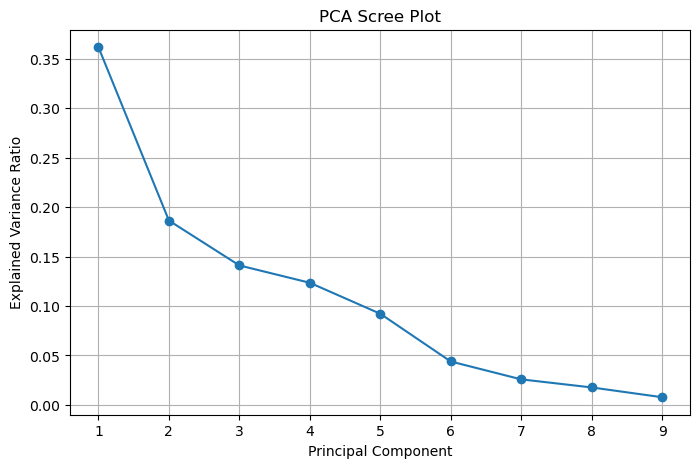

In [22]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(variance_ratios)+1), variance_ratios, marker='o')
plt.title("PCA Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.savefig(OUTPUT_DIR / "pca_scree_plot.png", dpi=300)
plt.show()


The first three principal components capture ~68% of total variance, representing the major structural differences across MENA countries. Additional components contribute marginal variance and mainly represent noise.

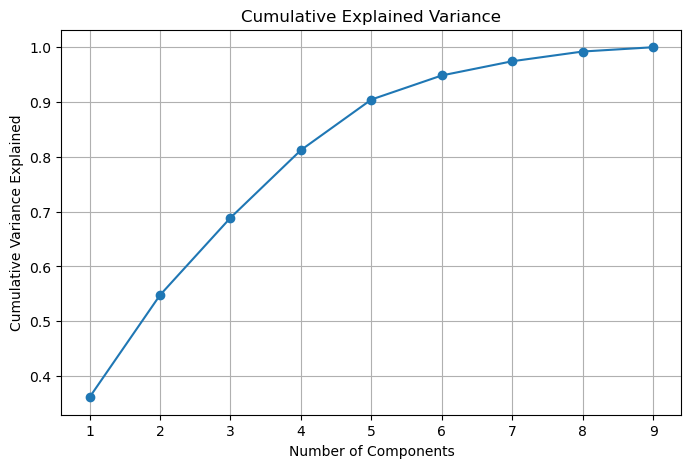

In [23]:
cum_var = np.cumsum(variance_ratios)
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.grid(True)
plt.savefig(OUTPUT_DIR / "pca_cumulative_variance.png", dpi=300)
plt.show()


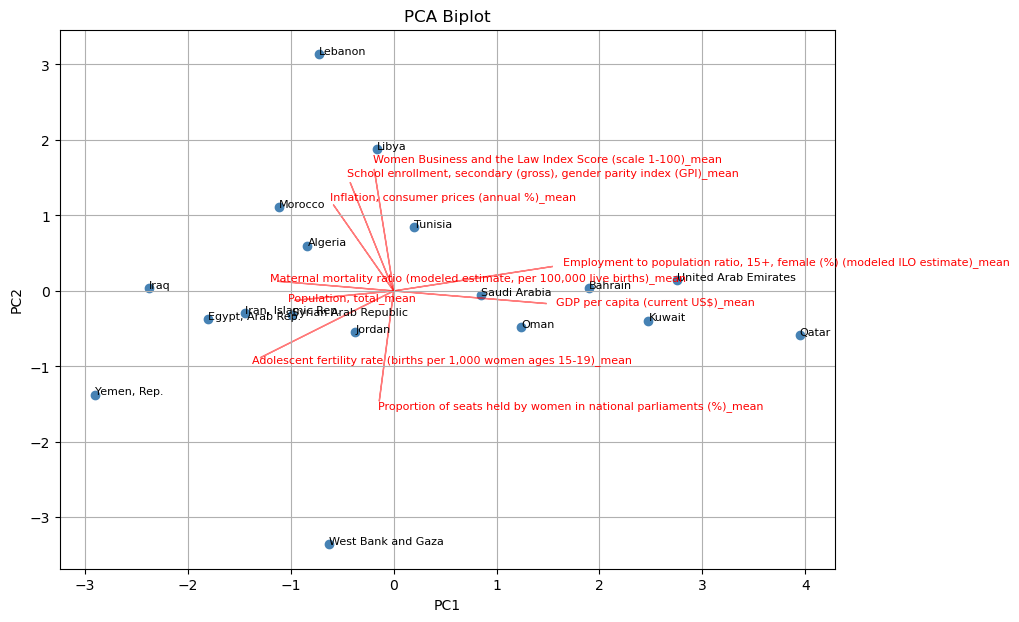

In [24]:
plt.figure(figsize=(10,7))
plt.scatter(pca_df["PC1"], pca_df["PC2"], c='steelblue')

for i, txt in enumerate(pca_df["country_name"]):
    plt.annotate(txt, (pca_df["PC1"][i], pca_df["PC2"][i]), fontsize=8)

# Add loadings (scaled for visibility)
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings.iloc[i,0]*3, loadings.iloc[i,1]*3,
              color='red', alpha=0.5)
    plt.text(loadings.iloc[i,0]*3.2, loadings.iloc[i,1]*3.2,
             feature, color='red', fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot")
plt.grid(True)
plt.savefig(OUTPUT_DIR / "pca_biplot.png", dpi=300)
plt.show()


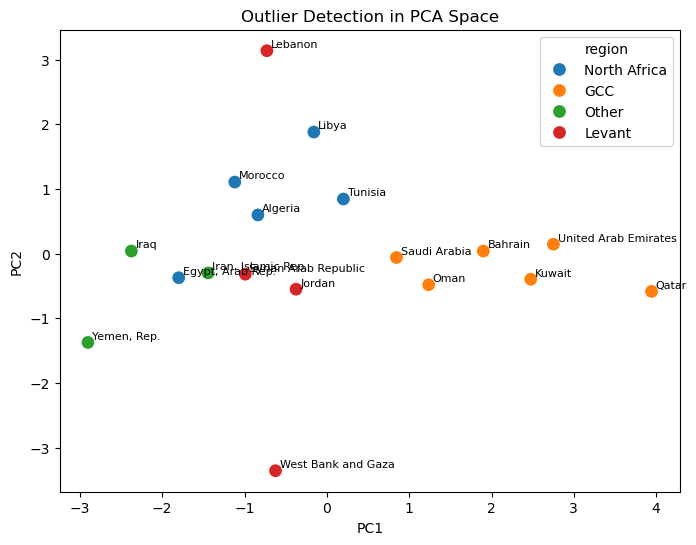

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", hue="region", data=pca_df, s=100)

for i, row in pca_df.iterrows():
    plt.text(row["PC1"]+0.05, row["PC2"]+0.05, row["country_name"], fontsize=8)

plt.title("Outlier Detection in PCA Space")
plt.savefig(OUTPUT_DIR / "pca_outlier_detection.png", dpi=300)
plt.show()


### Test Different Values of k (Elbow + Silhouette)

In [26]:
X_cluster = pca_df[["PC1", "PC2", "PC3"]].values


In [27]:
countries = pca_df["country_name"].tolist()
regions = pca_df["region"].tolist()

In [28]:
k_values = range(2, 9)
inertias = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_cluster)

    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))


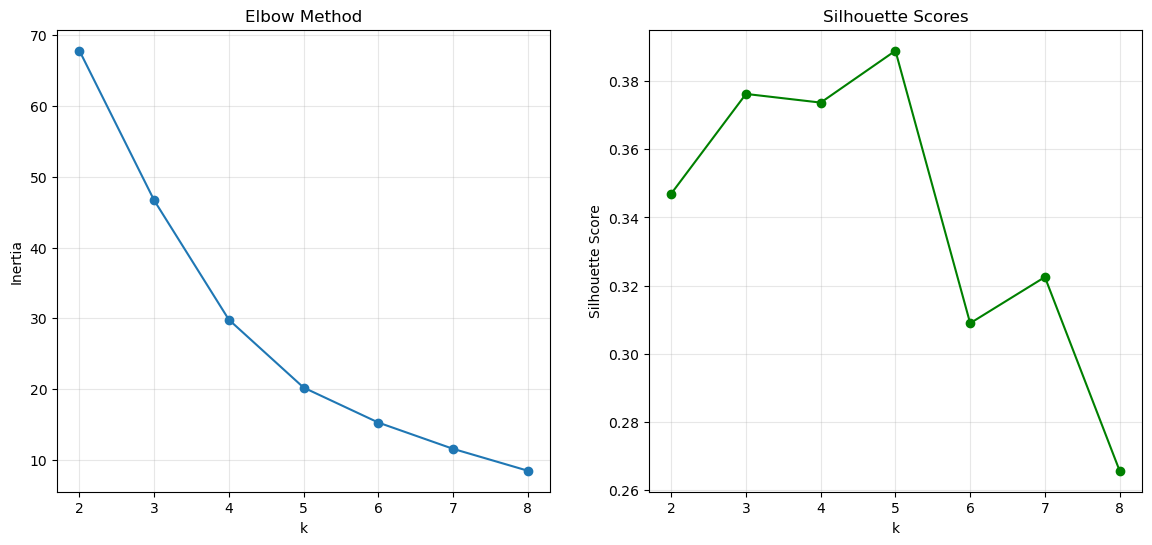


Best k based on silhouette = 5


In [15]:
# Plot elbow + silhouette
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Elbow
ax[0].plot(k_values, inertias, marker='o')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")
ax[0].grid(alpha=0.3)

# Silhouette
ax[1].plot(k_values, sil_scores, marker='o', color='green')
ax[1].set_title("Silhouette Scores")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette Score")
ax[1].grid(alpha=0.3)

plt.show()

print("\nBest k based on silhouette =", k_values[np.argmax(sil_scores)])

### Fit Final KMeans Model Using Optimal k

In [29]:
k_opt = k_values[np.argmax(sil_scores)]

kmeans = KMeans(n_clusters=k_opt, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_cluster)

pca_df["Cluster"] = cluster_labels

print("Cluster sizes:")
print(pca_df["Cluster"].value_counts())


Cluster sizes:
Cluster
1    6
2    6
3    4
0    1
4    1
Name: count, dtype: int64


### Visualize Clusters in PCA Space (PC1 vs PC2)

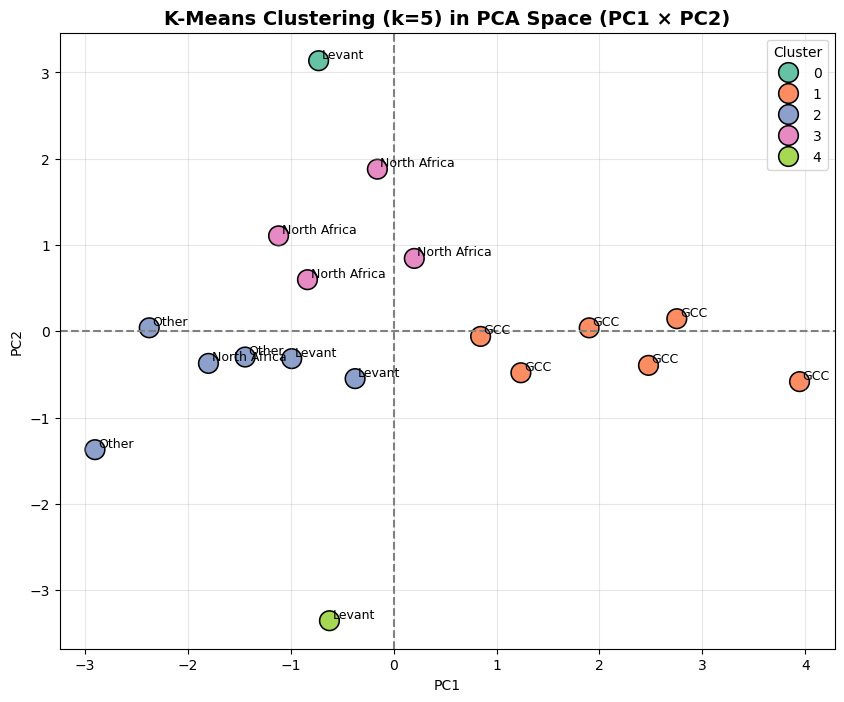

In [30]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="Cluster",
    palette="Set2",
    s=200,
    edgecolor="black"
)

for _, row in pca_df.iterrows():
    plt.text(row.PC1 + 0.03, row.PC2 + 0.03, row.region, fontsize=9)

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

plt.title(f"K-Means Clustering (k={k_opt}) in PCA Space (PC1 × PC2)", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.show()



Average silhouette = 0.38893377823771524


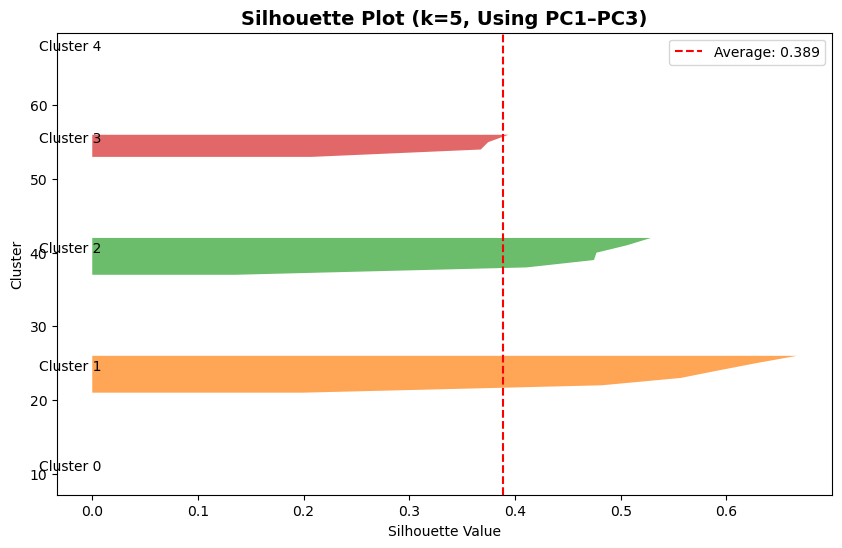

In [31]:
from sklearn.metrics import silhouette_samples
import numpy as np

sil_vals = silhouette_samples(X_cluster, cluster_labels)
avg_sil = np.mean(sil_vals)

print("Average silhouette =", avg_sil)

plt.figure(figsize=(10, 6))
y_lower = 10

for cluster in np.unique(cluster_labels):
    cluster_sil = sil_vals[cluster_labels == cluster]
    cluster_sil.sort()
    y_upper = y_lower + len(cluster_sil)

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cluster_sil,
        alpha=0.7
    )
    plt.text(-0.05, y_lower + len(cluster_sil) / 2, f"Cluster {cluster}")
    y_lower = y_upper + 10

plt.axvline(avg_sil, color="red", linestyle="--", label=f"Average: {avg_sil:.3f}")
plt.title(f"Silhouette Plot (k={k_opt}, Using PC1–PC3)", fontsize=14, fontweight='bold')
plt.xlabel("Silhouette Value")
plt.ylabel("Cluster")
plt.legend()
plt.show()


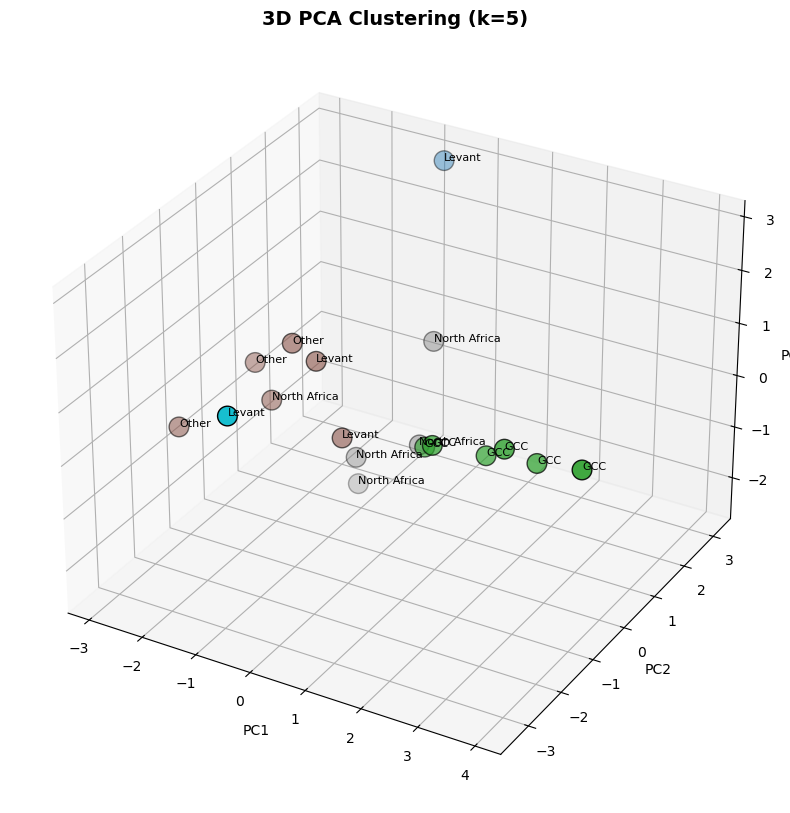

In [32]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_df["PC1"], pca_df["PC2"], pca_df["PC3"],
    c=pca_df["Cluster"], cmap="tab10",
    s=200, edgecolor="black"
)

for _, row in pca_df.iterrows():
    ax.text(row.PC1, row.PC2, row.PC3, row.region, fontsize=8)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title(f"3D PCA Clustering (k={k_opt})", fontsize=14, fontweight="bold")

plt.show()


In [33]:
ml_df["country_name"].dtype, pca_df["country_name"].dtype


(dtype('O'), dtype('O'))

In [34]:
ml_df["country_name"] = ml_df["country_name"].astype(str)
pca_df["country_name"] = pca_df["country_name"].astype(str)


In [35]:
ml_df.columns

Index(['country_name', 'Population, total_mean',
       'GDP per capita (current US$)_mean',
       'School enrollment, secondary (gross), gender parity index (GPI)_mean',
       'Proportion of seats held by women in national parliaments (%)_mean',
       'Women Business and the Law Index Score (scale 1-100)_mean',
       'Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean',
       'Adolescent fertility rate (births per 1,000 women ages 15-19)_mean',
       'Inflation, consumer prices (annual %)_mean',
       'Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean',
       'region'],
      dtype='object')

In [36]:
pca_df.head()

,country_name,region,PC1,PC2,PC3,Cluster
0,Algeria,North Africa,-0.837744,0.597726,-1.528005,3
1,Bahrain,GCC,1.900227,0.039329,-0.340081,1
2,"Egypt, Arab Rep.",North Africa,-1.799994,-0.372545,-0.168229,2
3,"Iran, Islamic Rep.",Other,-1.443357,-0.298715,0.983355,2
4,Iraq,Other,-2.375472,0.039955,0.165216,2


In [37]:
ml_df = ml_df.merge(
    pca_df[["country_name", "Cluster"]],
    on="country_name",
    how="left"
)

In [38]:
ml_df["Cluster"].value_counts(dropna=False)


Cluster
1    6
2    6
3    4
0    1
4    1
Name: count, dtype: int64

In [42]:
country_names = ml_df["country_name"].values


In [43]:
pc_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pc_cols)

# ADD THE COUNTRY NAMES BACK
pca_df["country_name"] = country_names

# move column to front (optional)
pca_df = pca_df[["country_name"] + pc_cols]


In [44]:
pca_df["Cluster"] = cluster_labels


In [45]:
pca_df.head()



,country_name,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Cluster
0,Algeria,-0.837744,0.597726,-1.528005,-0.095624,-0.702257,-0.137335,0.141079,-0.659615,-0.308707,3
1,Bahrain,1.900227,0.039329,-0.340081,-0.170821,-0.063872,-0.129657,-0.074608,0.345520,0.495636,1
2,"Egypt, Arab Rep.",-1.799994,-0.372545,-0.168229,2.279048,-0.561394,1.120786,-0.216897,0.106215,0.285203,2
3,"Iran, Islamic Rep.",-1.443357,-0.298715,0.983355,2.304485,-0.561044,-0.073520,0.075837,-0.660563,0.011879,2
4,Iraq,-2.375472,0.039955,0.165216,-0.658568,1.856444,1.002499,-0.838879,0.447198,-0.060468,2


### Create a Summary Table of Cluster Profiles

### Cluster Membership Tables

In [46]:
countries_by_cluster = ml_df.groupby("Cluster")["country_name"].apply(list)
countries_by_cluster

Cluster
0                                            [Lebanon]
1    [Bahrain, Kuwait, Oman, Qatar, Saudi Arabia, U...
2    [Egypt, Arab Rep., Iran, Islamic Rep., Iraq, J...
3                   [Algeria, Libya, Morocco, Tunisia]
4                                 [West Bank and Gaza]
Name: country_name, dtype: object

In [47]:
summary = {
    k: pca_df[pca_df["Cluster"] == k]["country_name"].tolist()
    for k in sorted(pca_df["Cluster"].unique())
}

summary


{0: ['Lebanon'],
 1: ['Bahrain',
  'Kuwait',
  'Oman',
  'Qatar',
  'Saudi Arabia',
  'United Arab Emirates'],
 2: ['Egypt, Arab Rep.',
  'Iran, Islamic Rep.',
  'Iraq',
  'Jordan',
  'Syrian Arab Republic',
  'Yemen, Rep.'],
 3: ['Algeria', 'Libya', 'Morocco', 'Tunisia'],
 4: ['West Bank and Gaza']}

In [48]:
cluster_names = {
    0: "Lebanon Outlier",
    1: "High-Income Empowerers",
    2: "Fragile States",
    3: "North African Reformers",
    4: "Palestine"
}


In [49]:
ml_df["Cluster_Name"] = ml_df["Cluster"].map(cluster_names)


### Cluster Profile Computation

#### Raw Mean Profiles

In [54]:
key_features = [
    'Population, total_mean',
    'GDP per capita (current US$)_mean',
    'School enrollment, secondary (gross), gender parity index (GPI)_mean',
    'Proportion of seats held by women in national parliaments (%)_mean',
    'Women Business and the Law Index Score (scale 1-100)_mean',
    'Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean',
    'Adolescent fertility rate (births per 1,000 women ages 15-19)_mean',
    'Inflation, consumer prices (annual %)_mean',
    'Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean'
]

cluster_profiles = ml_df.groupby("Cluster")[key_features].mean().round(2)
cluster_profiles


,"Population, total_mean",GDP per capita (current US$)_mean,"School enrollment, secondary (gross), gender parity index (GPI)_mean",Proportion of seats held by women in national parliaments (%)_mean,Women Business and the Law Index Score (scale 1-100)_mean,"Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean","Adolescent fertility rate (births per 1,000 women ages 15-19)_mean","Inflation, consumer prices (annual %)_mean","Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean"
Cluster,,,,,,,,,
0,5795453.43,7059.87,248972.76,4.02,52.95,18.36,22.17,47.38,22.79
1,8323447.87,39604.85,0.98,11.26,38.48,11.37,9.79,1.88,39.30
2,48093032.58,3373.30,33040.78,11.84,35.97,56.02,50.01,12.06,10.31
3,23667915.98,5314.23,55342.98,20.78,60.00,72.52,12.92,5.45,19.45
4,4441502.43,3355.66,1.10,248972.76,27.95,26.21,44.19,1.84,11.12


#### Normalized Profiles (z-score)

In [55]:
from sklearn.preprocessing import StandardScaler

# Copy cluster profiles
norm_profiles = cluster_profiles.copy()

# List of indicator columns
cols = norm_profiles.columns

# Z-score normalization
scaler = StandardScaler()
norm_profiles[cols] = scaler.fit_transform(norm_profiles[cols])

norm_profiles


,"Population, total_mean",GDP per capita (current US$)_mean,"School enrollment, secondary (gross), gender parity index (GPI)_mean",Proportion of seats held by women in national parliaments (%)_mean,Women Business and the Law Index Score (scale 1-100)_mean,"Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean","Adolescent fertility rate (births per 1,000 women ages 15-19)_mean","Inflation, consumer prices (annual %)_mean","Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean"
Cluster,,,,,,,,,
0,-0.742783,-0.334418,1.948589,-0.500080,0.844517,-0.791220,-0.344963,1.952730,0.209084
1,-0.589733,1.990291,-0.724364,-0.500007,-0.392342,-1.089592,-1.101365,-0.687035,1.781018
2,1.818013,-0.597752,-0.369649,-0.500001,-0.606890,0.816319,1.356025,-0.096424,-0.979151
3,0.339258,-0.459110,-0.130214,-0.499912,1.447134,1.520631,-0.910126,-0.479915,-0.108921
4,-0.824755,-0.599012,-0.724362,2.000000,-1.292419,-0.456138,1.000430,-0.689356,-0.902030


In [56]:
ml_df.columns

Index(['country_name', 'Population, total_mean',
       'GDP per capita (current US$)_mean',
       'School enrollment, secondary (gross), gender parity index (GPI)_mean',
       'Proportion of seats held by women in national parliaments (%)_mean',
       'Women Business and the Law Index Score (scale 1-100)_mean',
       'Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean',
       'Adolescent fertility rate (births per 1,000 women ages 15-19)_mean',
       'Inflation, consumer prices (annual %)_mean',
       'Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean',
       'region', 'Cluster', 'Cluster_Name'],
      dtype='object')

### Cluster Narratives

In [67]:
def generate_cluster_narrative(cluster_id, norm_df, cluster_names):
    profile = norm_df.loc[cluster_id]
    name = cluster_names.get(cluster_id, f"Cluster {cluster_id}")
    
    high_inds = profile[profile > 0.6].index.tolist()
    low_inds = profile[profile < -0.6].index.tolist()
    
    narrative = []
    narrative.append(f"### {name} — Cluster Narrative")
    
    # Identity introduction
    narrative.append(f"This cluster represents **{name}**, characterized by a distinct structural profile across gender, economic, demographic, and governance indicators.")
    
    # Strengths
    if high_inds:
        narrative.append("\n**Key Strengths:**")
        for ind in high_inds:
            narrative.append(f"- High performance in **{ind}**, indicating strong capacity or advancement in this area.")
    else:
        narrative.append("\n**Key Strengths:**")
        narrative.append("- No strong positive outliers. This cluster shows generally moderate performance across indicators.")
    
    # Weaknesses
    if low_inds:
        narrative.append("\n**Key Weaknesses:**")
        for ind in low_inds:
            narrative.append(f"- Low values in **{ind}**, reflecting structural challenges or persistent gender-development barriers.")
    else:
        narrative.append("\n**Key Weaknesses:**")
        narrative.append("- No major negative outliers. Weaknesses are moderate rather than severe.")
    
    # General interpretation
    narrative.append("\n**Interpretation:**")
    if "GDP per capita (current US$)_mean" in high_inds:
        narrative.append("- This group has **strong economic foundations**, which typically correlate with improved gender development outcomes.")
    if "Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean" in low_inds:
        narrative.append("- High maternal mortality suggests **health system weakness**, impacting women disproportionately.")
    if "Adolescent fertility rate (births per 1,000 women ages 15-19)_mean" in low_inds:
        narrative.append("- Low adolescent fertility reflects **delayed marriage and better reproductive health access**.")
    if "Adolescent fertility rate (births per 1,000 women ages 15-19)_mean" in high_inds:
        narrative.append("- High adolescent fertility indicates **early marriage/childbearing**, often linked to limited opportunities for young women.")
    if "Women Business and the Law Index Score (scale 1-100)_mean" in high_inds:
        narrative.append("- Strong **legal frameworks for women** support female autonomy, economic mobility, and entrepreneurship.")
    if "Proportion of seats held by women in national parliaments (%)_mean" in high_inds:
        narrative.append("- High female representation in parliament reflects **institutional gender inclusion**.")
    if "Proportion of seats held by women in national parliaments (%)_mean" in low_inds:
        narrative.append("- Low political representation indicates **gender exclusion in decision-making spaces**.")
    if "Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean" in high_inds:
        narrative.append("- Strong female labor market participation boosts **economic empowerment**.")
    if "Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean" in low_inds:
        narrative.append("- Low female employment reflects **labor market exclusion** or restrictive social norms.")
    
    narrative.append("\n---\n")
    
    return "\n".join(narrative)


In [72]:
cluster_texts = {}

for cid in norm_profiles.index:
    text = generate_cluster_narrative(cid, norm_profiles, cluster_names)
    cluster_texts[cid] = text
    print(text)


for cid, text in cluster_texts.items():
    name = cluster_names[cid].replace(" ", "_")
    with open(os.path.join(OUTPUT_DIR, f"cluster_{cid}_{name}.md"), "w") as f:
        f.write(text)

### Lebanon Outlier — Cluster Narrative
This cluster represents **Lebanon Outlier**, characterized by a distinct structural profile across gender, economic, demographic, and governance indicators.

**Key Strengths:**
- High performance in **School enrollment, secondary (gross), gender parity index (GPI)_mean**, indicating strong capacity or advancement in this area.
- High performance in **Women Business and the Law Index Score (scale 1-100)_mean**, indicating strong capacity or advancement in this area.
- High performance in **Inflation, consumer prices (annual %)_mean**, indicating strong capacity or advancement in this area.

**Key Weaknesses:**
- Low values in **Population, total_mean**, reflecting structural challenges or persistent gender-development barriers.
- Low values in **Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean**, reflecting structural challenges or persistent gender-development barriers.

**Interpretation:**
- High maternal mortality sugge

### Cluster Radar Charts

In [73]:

def plot_normalized_radar(cluster_id, norm_df, cluster_names):
    data = norm_df.loc[cluster_id].values
    labels = norm_df.columns
    
    # Number of variables
    N = len(labels)
    
    # Angle setup
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    data = np.concatenate((data, [data[0]]))
    angles = np.concatenate((angles, [angles[0]]))
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    ax.plot(angles, data, linewidth=2)
    ax.fill(angles, data, alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8)
    
    cluster_title = cluster_names.get(cluster_id, f"Cluster {cluster_id}")
    ax.set_title(f"{cluster_title} – Normalized Profile", fontsize=14, fontweight='bold')
    
     # --- Detect Project Root (folder that contains "outputs") ---
    current = os.getcwd()
    while current != "/" and "worldbank_tableau_project" not in os.listdir(current):
        current = os.path.dirname(current)

    #project_root = os.path.join(current, "worldbank_tableau_project")

    # Final save directory
    #save_dir = os.path.join(project_root, "outputs", "clustering")
    #os.makedirs(save_dir, exist_ok=True)

    # 🔥 USE CLUSTER NAME (SAFER FILE NAME)
    safe_name = cluster_title.replace(" ", "_").replace("/", "_")
    save_path = os.path.join(OUTPUT_DIR, f"radar_{safe_name}.png")


    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved correctly to: {save_path}")

    plt.show()
    plt.close(fig)


Saved correctly to: /Users/daniehbenotman/Desktop/worldbank_tableau_project/worldbank_tableau_project/outputs/clustering/radar_Lebanon_Outlier.png


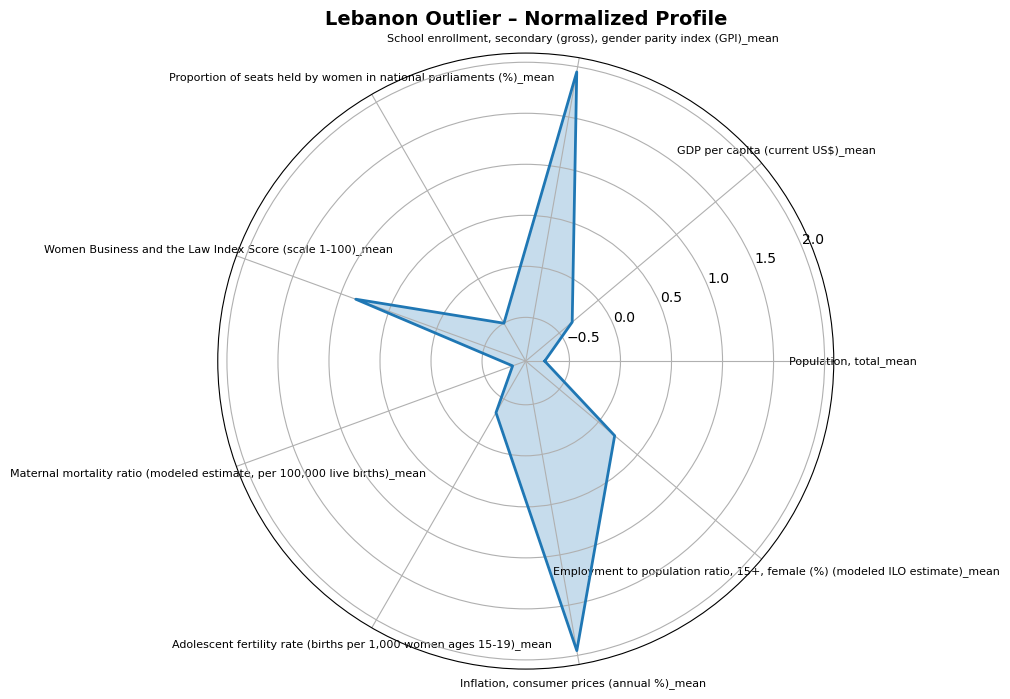

Saved correctly to: /Users/daniehbenotman/Desktop/worldbank_tableau_project/worldbank_tableau_project/outputs/clustering/radar_High-Income_Empowerers.png


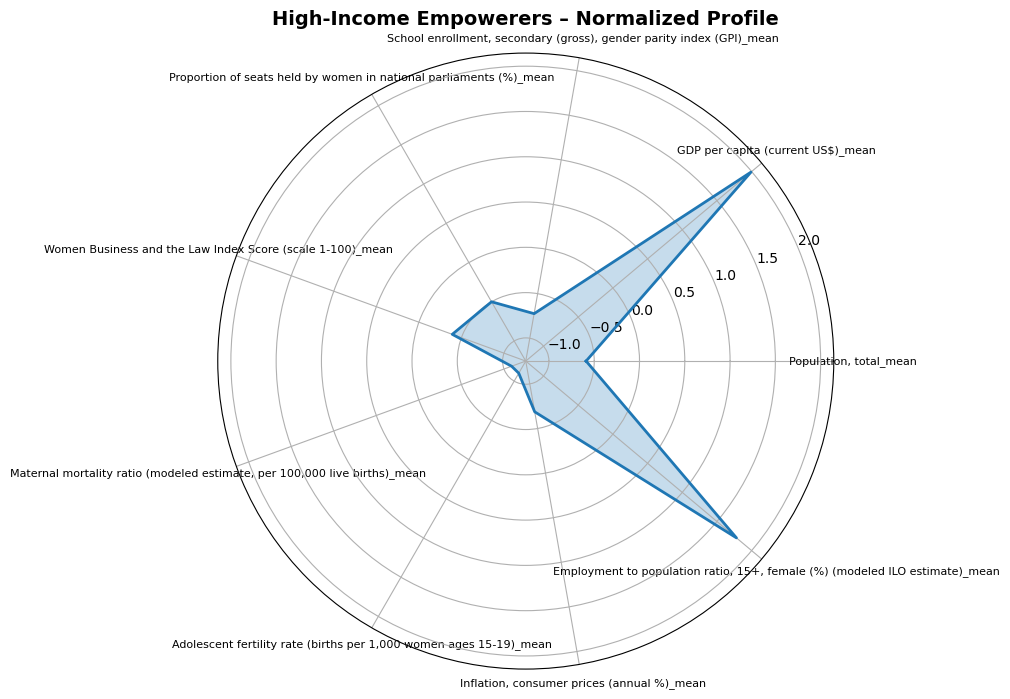

Saved correctly to: /Users/daniehbenotman/Desktop/worldbank_tableau_project/worldbank_tableau_project/outputs/clustering/radar_Fragile_States.png


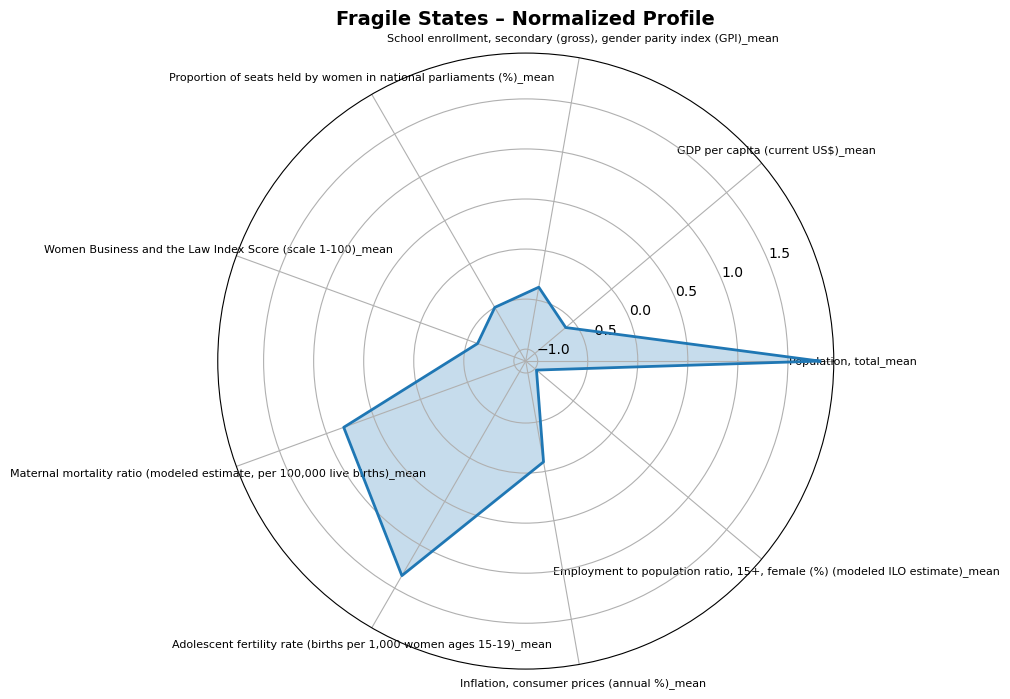

Saved correctly to: /Users/daniehbenotman/Desktop/worldbank_tableau_project/worldbank_tableau_project/outputs/clustering/radar_North_African_Reformers.png


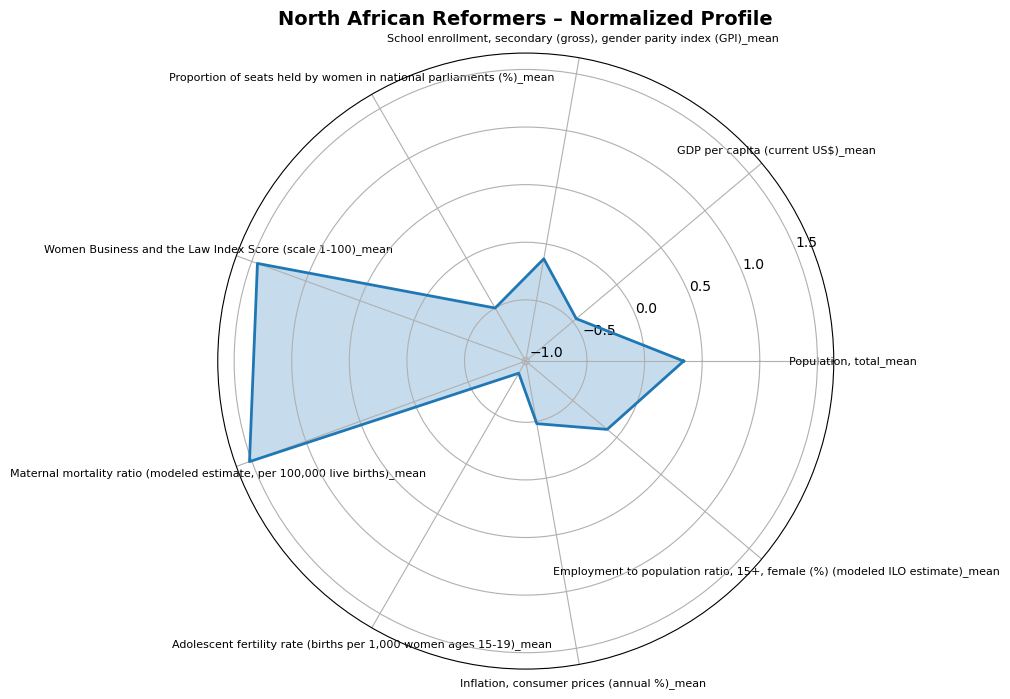

Saved correctly to: /Users/daniehbenotman/Desktop/worldbank_tableau_project/worldbank_tableau_project/outputs/clustering/radar_Palestine.png


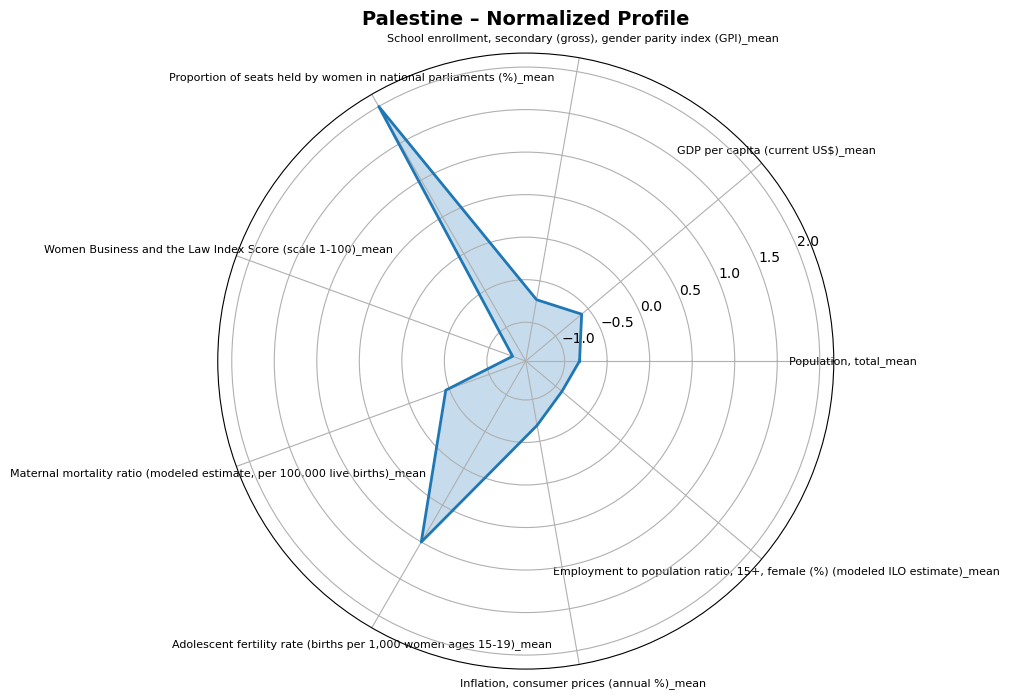

In [69]:
for cid in norm_profiles.index:
    plot_normalized_radar(cid, norm_profiles, cluster_names)

In [57]:
export_df = ml_df[["country_name", "Cluster", "Cluster_Name"]]
export_df.to_csv("../worldbank_tableau_project/outputs/cluster_assignments.csv", index=False)


In [64]:
cluster_means = ml_df.groupby("Cluster")[features].mean()
cluster_means.to_csv("../worldbank_tableau_project/outputs/clustering/cluster_means.csv")


### Cluster Quality Evaluation (Silhouette Per Cluster)

In [58]:
from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(X_pca, ml_df["Cluster"])
ml_df["Silhouette"] = sil_samples


In [59]:
overall_sil = silhouette_score(X_pca, ml_df["Cluster"])
print("Overall Silhouette Score:", overall_sil)

Overall Silhouette Score: 0.24937888278880266


In [60]:
cluster_silhouette = ml_df.groupby("Cluster")["Silhouette"].mean().sort_values(ascending=False)
cluster_silhouette


Cluster
1    0.434021
3    0.277761
2    0.128941
0    0.000000
4    0.000000
Name: Silhouette, dtype: float64

In [61]:
scores_per_cluster = ml_df.groupby("Cluster")[["country_name", "Silhouette"]] \
                          .apply(lambda g: g.sort_values("Silhouette", ascending=True))

scores_per_cluster


country_name  Silhouette
Cluster                                     
0       7                Lebanon    0.000000
1       12          Saudi Arabia    0.165124
        10                  Oman    0.375466
        1                Bahrain    0.473062
        11                 Qatar    0.474285
        15  United Arab Emirates    0.545105
        6                 Kuwait    0.571086
2       5                 Jordan   -0.126047
        4                   Iraq    0.087917
        13  Syrian Arab Republic    0.171913
        2       Egypt, Arab Rep.    0.193101
        17           Yemen, Rep.    0.197390
        3     Iran, Islamic Rep.    0.249374
3       8                  Libya    0.122655
        14               Tunisia    0.254235
        0                Algeria    0.356890
        9                Morocco    0.377264
4       16    West Bank and Gaza    0.000000

In [63]:
scores_per_cluster.to_csv("../worldbank_tableau_project/outputs/clustering/silhouette_scores_per_country.csv", index=False)

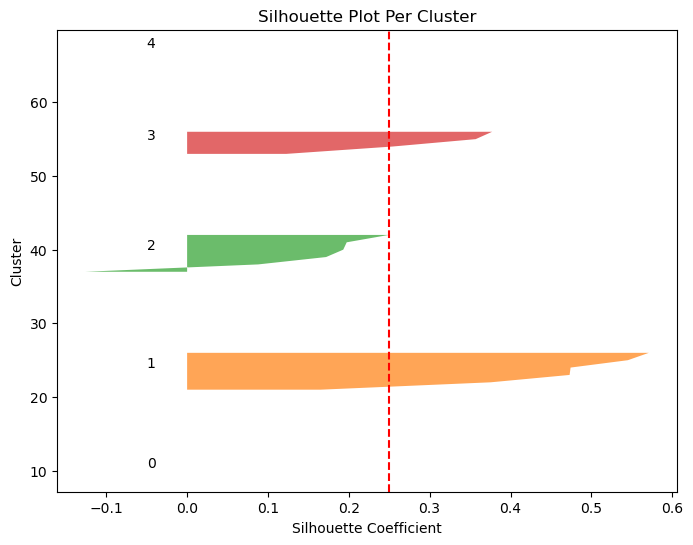

In [62]:
import matplotlib.pyplot as plt
import numpy as np

def plot_silhouette_by_cluster(X, labels):
    from sklearn.metrics import silhouette_samples
    sil_vals = silhouette_samples(X, labels)
    clusters = np.unique(labels)
    y_lower = 10
    fig, ax = plt.subplots(figsize=(8, 6))

    for cluster in clusters:
        cluster_sil_vals = sil_vals[labels == cluster]
        cluster_sil_vals.sort()
        
        y_upper = y_lower + len(cluster_sil_vals)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_sil_vals,
            alpha=0.7
        )
        ax.text(-0.05, (y_lower + y_upper) / 2, str(cluster))
        y_lower = y_upper + 10
    
    ax.set_title("Silhouette Plot Per Cluster")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster")
    ax.axvline(np.mean(sil_vals), color="red", linestyle="--")
    plt.savefig("../worldbank_tableau_project/outputs/clustering/silhouette_per_cluster.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_silhouette_by_cluster(X_pca, ml_df["Cluster"].values)


In [75]:
ml_df.to_csv("data/3clustering_3.csv", index=False)

In [ ]:
ml_df.to_csv("../worldbank_tableau_project/clustering/country_silhouette_scores.csv", index=False)


In [76]:
pca_df.to_csv("data/3pca_clusters.csv", index=False)

In [77]:
pca_df.head()

,country_name,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Cluster
0,Algeria,-0.837744,0.597726,-1.528005,-0.095624,-0.702257,-0.137335,0.141079,-0.659615,-0.308707,3
1,Bahrain,1.900227,0.039329,-0.340081,-0.170821,-0.063872,-0.129657,-0.074608,0.345520,0.495636,1
2,"Egypt, Arab Rep.",-1.799994,-0.372545,-0.168229,2.279048,-0.561394,1.120786,-0.216897,0.106215,0.285203,2
3,"Iran, Islamic Rep.",-1.443357,-0.298715,0.983355,2.304485,-0.561044,-0.073520,0.075837,-0.660563,0.011879,2
4,Iraq,-2.375472,0.039955,0.165216,-0.658568,1.856444,1.002499,-0.838879,0.447198,-0.060468,2


In [78]:
structure = ml_df[["country_name", "Cluster", "Cluster_Name"]]

In [79]:
structure.head()

,country_name,Cluster,Cluster_Name
0,Algeria,3,North African Reformers
1,Bahrain,1,High-Income Empowerers
2,"Egypt, Arab Rep.",2,Fragile States
3,"Iran, Islamic Rep.",2,Fragile States
4,Iraq,2,Fragile States


In [81]:
c_df = pca_df.merge(
    structure,
    on = ['country_name','Cluster'],
    how = 'left'
)
c_df.head()

,country_name,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Cluster,Cluster_Name
0,Algeria,-0.837744,0.597726,-1.528005,-0.095624,-0.702257,-0.137335,0.141079,-0.659615,-0.308707,3,North African Reformers
1,Bahrain,1.900227,0.039329,-0.340081,-0.170821,-0.063872,-0.129657,-0.074608,0.345520,0.495636,1,High-Income Empowerers
2,"Egypt, Arab Rep.",-1.799994,-0.372545,-0.168229,2.279048,-0.561394,1.120786,-0.216897,0.106215,0.285203,2,Fragile States
3,"Iran, Islamic Rep.",-1.443357,-0.298715,0.983355,2.304485,-0.561044,-0.073520,0.075837,-0.660563,0.011879,2,Fragile States
4,Iraq,-2.375472,0.039955,0.165216,-0.658568,1.856444,1.002499,-0.838879,0.447198,-0.060468,2,Fragile States


In [82]:
c_df.to_csv('data/Main_Clustering.csv',index=False)